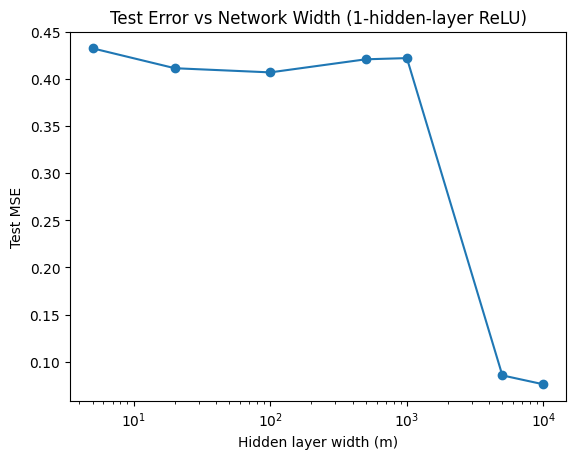

([np.float64(0.42446010695684655),
  np.float64(0.3947795663814269),
  np.float64(0.3882284762488628),
  np.float64(0.3971944903227341),
  np.float64(0.3981815133948173),
  np.float64(0.07480369643086855),
  np.float64(0.06537243580994992)],
 [np.float64(0.4323209674960675),
  np.float64(0.4112275691214096),
  np.float64(0.40681578212762454),
  np.float64(0.4206821369163699),
  np.float64(0.42194670543070695),
  np.float64(0.08561421986369763),
  np.float64(0.07615691692977834)])

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Target function
def f(x):
    return np.sin(4 * np.pi * x)

# Generate training and test data
n_train = 100
n_test = 1000

X_train = np.random.rand(n_train, 1)
y_train = f(X_train).ravel() + 0.1 * np.random.randn(n_train)

X_test = np.linspace(0, 1, n_test).reshape(-1, 1)
y_test = f(X_test).ravel()

# Widths to try
widths = [5, 20, 100, 500, 1000, 5000, 10000]

train_errors = []
test_errors = []

for m in widths:
    model = MLPRegressor(
        hidden_layer_sizes=(m,),
        activation='relu',
        solver='adam',
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plot test error vs width
plt.figure()
plt.plot(widths, test_errors, marker='o')
plt.xscale('log')
plt.xlabel('Hidden layer width (m)')
plt.ylabel('Test MSE')
plt.title('Test Error vs Network Width (1-hidden-layer ReLU)')
plt.show()

train_errors, test_errors


In [3]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(0)

def f(x):
    return np.sin(4 * np.pi * x)

# Data sizes
n_train = 100
n_test = 1000
noise_std = 0.1

# Fixed datasets (same across runs for fair comparison)
X_train = np.random.rand(n_train, 1)
y_train = f(X_train).ravel() + noise_std * np.random.randn(n_train)

X_test = np.linspace(0, 1, n_test).reshape(-1, 1)
y_test_clean = f(X_test).ravel()
y_test_noisy = y_test_clean + noise_std * np.random.randn(n_test)

widths = [5, 20, 100, 500]
n_inits = 5

rows = []

for m in widths:
    for seed in range(n_inits):
        model = MLPRegressor(
            hidden_layer_sizes=(m,),
            activation='relu',
            solver='adam',
            max_iter=5000,
            random_state=seed
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse_clean = mean_squared_error(y_test_clean, y_test_pred)
        test_mse_noisy = mean_squared_error(y_test_noisy, y_test_pred)

        # Compute Euclidean norm of all parameters
        param_sq_sum = 0.0
        for W in model.coefs_:
            param_sq_sum += np.sum(W**2)
        for b in model.intercepts_:
            param_sq_sum += np.sum(b**2)
        param_norm = np.sqrt(param_sq_sum)

        rows.append({
            "width_m": m,
            "seed": seed,
            "train_mse": train_mse,
            "test_mse_noisy": test_mse_noisy,
            "test_mse_clean": test_mse_clean,
            "param_l2_norm": param_norm
        })

df = pd.DataFrame(rows)
df


,width_m,seed,train_mse,test_mse_noisy,test_mse_clean,param_l2_norm
0,5,0,0.531082,0.543299,0.536419,2.026486
1,5,1,0.528192,0.583763,0.575363,2.174506
2,5,2,0.497951,0.522479,0.514110,1.726260
3,5,3,0.545281,0.538444,0.532294,1.869352
4,5,4,0.500357,0.491517,0.484026,2.316809
5,20,0,0.482660,0.486506,0.478116,2.260594
6,20,1,0.457127,0.464243,0.454704,2.551380
7,20,2,0.450497,0.458081,0.448211,2.295802
8,20,3,0.437098,0.444529,0.434196,2.453198
9,20,4,0.453808,0.463048,0.452972,2.391574


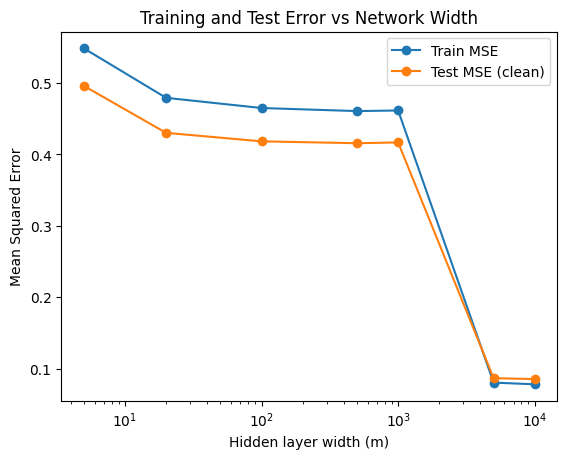

([np.float64(0.5482137509075418),
  np.float64(0.4789401805198086),
  np.float64(0.464640263238295),
  np.float64(0.46036107494372003),
  np.float64(0.46120894327144335),
  np.float64(0.08032982256649539),
  np.float64(0.07789675088716459)],
 [np.float64(0.4957139430746815),
  np.float64(0.4299132256297308),
  np.float64(0.4180075351931096),
  np.float64(0.4153880907150909),
  np.float64(0.41647995406071675),
  np.float64(0.08649178997993387),
  np.float64(0.08522689614406202)])

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(1)

def f(x):
    return np.sin(4 * np.pi * x)

# Data
n_train = 100
n_test = 1000
noise_std = 0.1

X_train = np.random.rand(n_train, 1)
y_train = f(X_train).ravel() + noise_std * np.random.randn(n_train)

X_test = np.linspace(0, 1, n_test).reshape(-1, 1)
y_test_clean = f(X_test).ravel()

widths = [5, 20, 100, 500, 1000, 5000, 10000]
n_inits = 5

train_means = []
test_means = []

for m in widths:
    train_errs = []
    test_errs = []

    for seed in range(n_inits):
        model = MLPRegressor(
            hidden_layer_sizes=(m,),
            activation='relu',
            solver='adam',
            max_iter=5000,
            random_state=seed
        )
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_errs.append(mean_squared_error(y_train, y_train_pred))
        test_errs.append(mean_squared_error(y_test_clean, y_test_pred))

    train_means.append(np.mean(train_errs))
    test_means.append(np.mean(test_errs))

# Plot
plt.figure()
plt.plot(widths, train_means, marker='o', label='Train MSE')
plt.plot(widths, test_means, marker='o', label='Test MSE (clean)')
plt.xscale('log')
plt.xlabel('Hidden layer width (m)')
plt.ylabel('Mean Squared Error')
plt.title('Training and Test Error vs Network Width')
plt.legend()
plt.show()

train_means, test_means


Width (m) | Train MSE | Test MSE
------------------------------------
        5 |  0.348150 | 0.836611
       20 |  0.370685 | 0.553716
      100 |  0.360179 | 0.678613
      500 |  0.375382 | 0.680675
     1000 |  0.373420 | 0.684347
  2000000 |  0.368529 | 0.648955


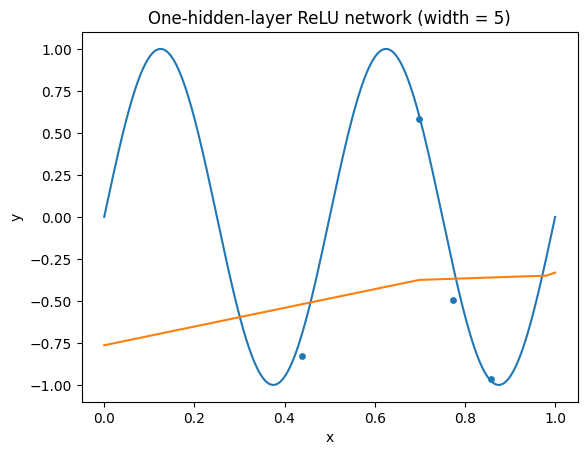

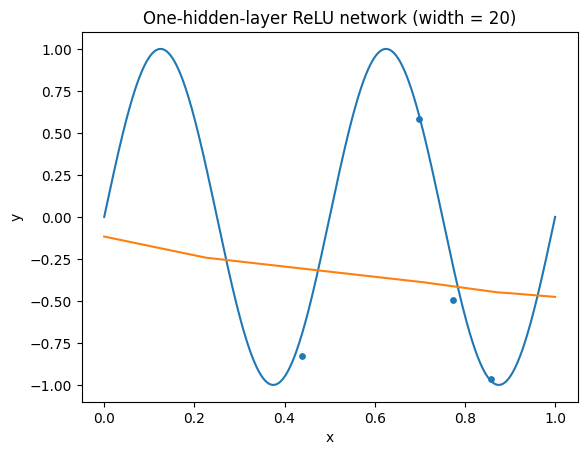

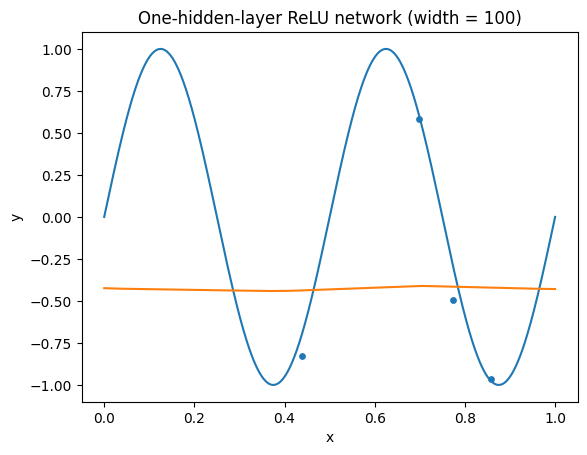

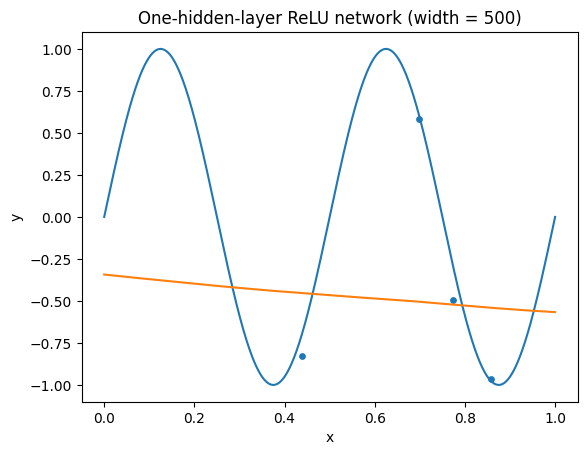

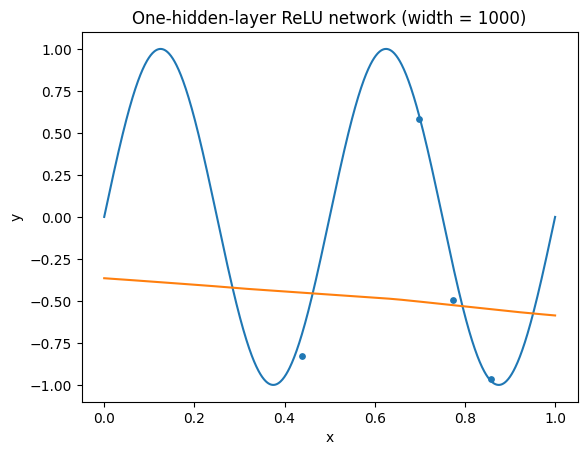

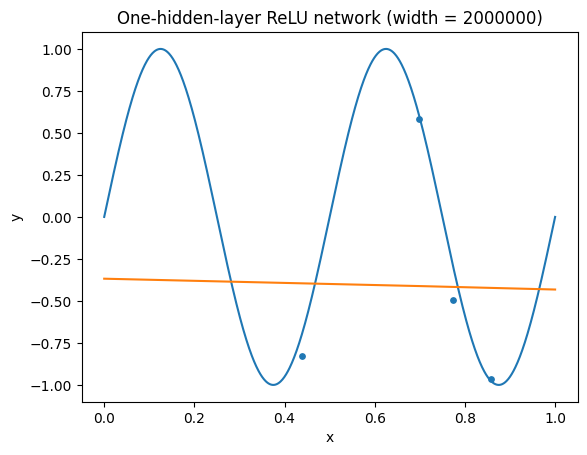

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Reproducibility
rng = np.random.default_rng(42)

# Target function
def f(x):
    return np.sin(4 * np.pi * x)

# Generate training data
n_train = 4
X_train = rng.uniform(0, 1, size=(n_train, 1))
noise = rng.normal(0, 0.1, size=n_train)
y_train = f(X_train[:, 0]) + noise

# Generate test data
n_test = 1000
X_test = np.linspace(0, 1, n_test).reshape(-1, 1)
y_test = f(X_test[:, 0])

widths = [5, 20, 100, 500, 1000, 2_000_000]
results = []

models = {}

for m in widths:
    model = MLPRegressor(
        hidden_layer_sizes=(m,),
        activation='relu',
        solver='adam',
        max_iter=500000,
        random_state=42,
        alpha=0.0  # No regularization
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    results.append((m, train_mse, test_mse))
    models[m] = y_test_pred

# Print results table
print("Width (m) | Train MSE | Test MSE")
print("-" * 36)
for m, tr, te in results:
    print(f"{m:9d} | {tr:9.6f} | {te:8.6f}")

# Plot predictions for each width
for m in widths:
    plt.figure()
    plt.scatter(X_train[:, 0], y_train, s=15)
    plt.plot(X_test[:, 0], y_test)
    plt.plot(X_test[:, 0], models[m])
    plt.title(f"One-hidden-layer ReLU network (width = {m})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()
